# Data Preprocessing and Feature Engineering in Machine Learning


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Exploration and Preprocessing:

In [2]:
df = pd.read_csv("adult_with_headers.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.shape

(32561, 15)

In [6]:
df.dtypes


age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [7]:
# missing values :
df.isnull().sum().sum()

np.int64(0)

In [8]:
# Apply scaling techniques to numerical features

num_features = df.select_dtypes(include = ['int64','float64']).columns.tolist()

In [9]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

In [10]:
df_std=df.copy()
df_minmax=df.copy()

In [11]:
df_std[num_features] = scaler_std.fit_transform(df[num_features])
df_minmax[num_features] = scaler_minmax.fit_transform(df[num_features])

In [12]:
print("\nStandard Scaled Sample:\n",df_std[num_features].head())
print("\nMin-Max Scaled Sample:\n", df_minmax[num_features].head())


Standard Scaled Sample:
         age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   
3  1.057047  0.425801      -1.197459     -0.145920      -0.21666   
4 -0.775768  1.408176       1.134739     -0.145920      -0.21666   

   hours_per_week  
0       -0.035429  
1       -2.222153  
2       -0.035429  
3       -0.035429  
4       -0.035429  

Min-Max Scaled Sample:
         age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.301370  0.044302       0.800000       0.02174           0.0   
1  0.452055  0.048238       0.800000       0.00000           0.0   
2  0.287671  0.138113       0.533333       0.00000           0.0   
3  0.493151  0.151068       0.400000       0.00000           0.0   
4  0.150685  0.221488       0.800000       0.00000           0.0   

   hours_pe

**Standard Scaling** (Z-score normalization):

*   Transforms features so they have mean = 0 and std = 1.
*   Best when data is roughly normally distributed.
*   Useful for models that assume normalized data: Linear/Logistic Regression, PCA, SVM, K-Means.

**Min-Max Scaling** (Normalization):

*   Scales all values into a fixed range (usually 0 to 1).

*   Best when features need to be bounded.
*   Works well for distance-based models like KNN, Neural Networks, Gradient Descent optimizers.
*   More sensitive to outliers compared to StandardScaler


## 2. Encoding Techniques:


In [13]:
# Apply One-Hot Encoding to categorical variables

df_encoded=df.copy()

In [14]:
categorical_features=df_encoded.select_dtypes(include='object').columns.drop("income")

In [15]:
for col in categorical_features:
  if df_encoded[col].nunique()<5:
    df_encoded=pd.get_dummies(df_encoded,columns=[col],drop_first=True)
  else:
    le=LabelEncoder()
    df_encoded[col]=le.fit_transform(df_encoded[col])

In [16]:
df_encoded["income"]=LabelEncoder().fit_transform(df_encoded["income"])

In [17]:
df_encoded.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Male
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,0,True
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,0,True
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,0,True
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,0,True
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,0,False


## 3. Feature Engineering:

In [18]:
df_engineered=df_encoded.copy()

In [19]:
df_engineered["capital_diff"]=df_engineered["capital_gain"] - df_engineered["capital_loss"]
df_engineered["hours_per_week_bin"] = pd.cut(df_engineered["hours_per_week"],
                                             bins=[0, 20, 40, 60, 100],
                                             labels=["part-time", "full-time", "overtime", "extreme"])

In [20]:
df_engineered["hours_per_week_bin"] = LabelEncoder().fit_transform(df_engineered["hours_per_week_bin"].astype(str))
df_engineered["capital_gain_log"] = df_engineered["capital_gain"].apply(lambda x: np.log1p(x))

In [21]:
df_engineered.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Male,capital_diff,hours_per_week_bin,capital_gain_log
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,0,True,2174,1,7.684784
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,0,True,0,3,0.000000
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,0,True,0,1,0.000000
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,0,True,0,1,0.000000
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,0,False,0,1,0.000000


In [22]:
## 4. Feature Selection:

In [23]:
# Isolation Forest algorithm to identify and remove outliers:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
yhat = iso.fit_predict(df_engineered[num_features])


In [24]:
# create a boolean mask:
mask = yhat != -1

# Use the mask to filter the DataFrame
df_no_outliers = df_engineered[mask]

In [25]:
print("\nShape before outlier removal:", df_engineered.shape)
print("Shape after outlier removal:", df_no_outliers.shape)


Shape before outlier removal: (32561, 18)
Shape after outlier removal: (32235, 18)


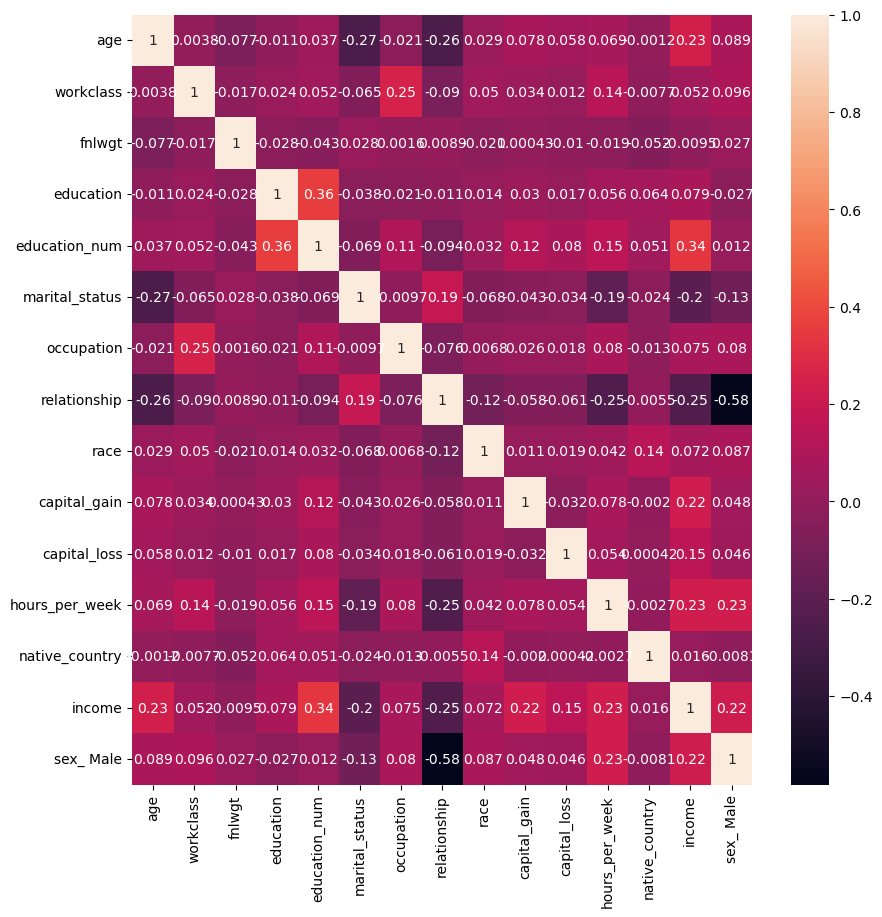

In [26]:
plt.figure(figsize=(10,10))
corr = df_encoded.corr()
ax=sns.heatmap(corr, annot=True)
plt.show()

In [27]:
# Apply the PPS (Predictive Power Score) to find and discuss the relationships between features




In [33]:
pip install ppscore 

  Using cached ppscore-1.3.0-py2.py3-none-any.whl
  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... one
  error: subprocess-exited-with-error
  
  × Building wheel for pandas (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [2773 lines of output]
      <string>:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
      /private/var/folders/hf/bzjj7rqn5bb5pbw837t8l1080000gn/T/pip-build-env-2wtx5ady/overlay/lib/python3.13/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consi

In [32]:
## PPS Matrix Visualization
pps_matrix = pps.matrix(df_no_outliers)

NameError: name 'pps' is not defined

In [ ]:
pps_matrix['ppscore'] = pd.to_numeric(pps_matrix['ppscore'], errors='coerce')

In [ ]:
heatmap_data = pps_matrix.pivot_table(index='x', columns='y', values='ppscore', aggfunc='mean', fill_value=0)

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, cmap='Blues')
plt.title("PPS Matrix Heatmap")
plt.show()